In [29]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.integrate import dblquad
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Initial conditions
C_0 = 100
W_x_0 = W_y_0 = (w_0 * np.sqrt(n_0 * alpha)) / (np.sqrt(w_0**4 + (0-z_w)**2))
T_x_0 = T_y_0 = 0
X_0 = Y_0 = 0
F_x_0 = F_y_0 = (-0.5 * n_0 * alpha * (0-z_w)) / (w_0**4 + (0-z_w)**2)
P_0 = np.arctan(z_w / w_0**2)

# Constants
w_0 = 5
n_0 = 1.000277
z_w = 50
alpha = 0.002
dndT = -7.7*10**(-4) / 770 * 0.002
gamma = 0.5
n = n_0
xi = 1
###
rho = 1.225 
c_rho = 1005  
kappa = 0.025  
alpha_loss = 0.01 

# Define the (x, y) grid globally
x_cor = np.linspace(-10, 10, 10)
y_cor = np.linspace(-10, 10, 10)
x_grid, y_grid = np.meshgrid(x_cor, y_cor)

def heat_profile(system):
    C, W_x, W_y, T_x, T_y_0, X, Y, F_x, F_y, P = system
    T = np.zeros_like(x_grid)
    for i in range(10):
        for j in range(10):
            T[i, j] = solve_heat_equation(x_grid[i, j], y_grid[i, j], X, Y, W_x, W_y)
    return -dndT * T


def solve_heat_equation(x, y, X, Y, W_x, W_y):
    f = lambda x_prime, y_prime: (1/2 * np.log((x - x_prime)**2 + (y - y_prime)**2))
    g = lambda x_prime, y_prime: (np.exp(-W_x**2 * (x_prime - X)**2) * np.exp(-W_y**2 * (y_prime - Y)**2))
    integrand = lambda x_prime, y_prime: f(x_prime, y_prime) * g(x_prime, y_prime)
    result, _ = dblquad(integrand, X-1, X+1, Y-1, Y+1)
    return result

def transverse_integral(turb_grid, mode_function, x_grid, y_grid, upsilon):
    vectorized_mode_function = np.vectorize(mode_function)
    mode_grid = vectorized_mode_function(x_grid, y_grid)
    product = turb_grid * mode_grid
    dx = (x_cor[1] - x_cor[0])
    dy = (y_cor[1] - y_cor[0])
    return np.sum(product) * dx * dy * 1

def beam_system(z, y):
    C, W_x, W_y, T_x, T_y, X, Y, F_x, F_y, P = y
    delta_n_thermal = heat_profile(y)
    upsilon = (1 / (2 * np.pi)) * (1 / kappa) * ((alpha / (rho * c_rho)) * C**2 * (W_x * W_y) / np.pi * np.exp(-alpha_loss * z))

    return [
        0,
        (2 / (n * xi)) * F_x * W_x,
        (2 / (n * xi)) * F_y * W_y,
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_x**2 * (x - X) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -n * gamma**2 * transverse_integral(delta_n_thermal, lambda x, y: 4 * W_y**2 * (y - Y) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        -2 * T_x,
        -2 * T_y,
        (-W_x**4 / (2 * n * xi)) + (2 * F_x**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_x**2 * (1 - 2 * W_x**2 * (x - X)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        (-W_y**4 / (2 * n * xi)) + (2 * F_y**2 / (n * xi)) + (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: W_y**2 * (1 - 2 * W_y**2 * (y - Y)) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon),
        ((W_x**2 + W_y**2) / (2 * n * xi)) - (gamma**2 / xi) * transverse_integral(delta_n_thermal, lambda x, y: (2 - W_x**2 * (x - X)**2 - W_y**2 * (y - Y)**2) * (abs(alpha)**2 / C**2), x_grid, y_grid, upsilon)
    ]


y0 = [C_0, W_x_0, W_y_0, T_x_0, T_y_0, X_0, Y_0, F_x_0, F_y_0, P_0]
z_range = (0, 10000)
sol = solve_ivp(beam_system, z_range, y0, method='RK45', t_eval=np.linspace(z_range[0], z_range[1], 100), dense_output=True)


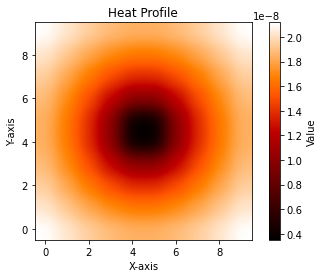

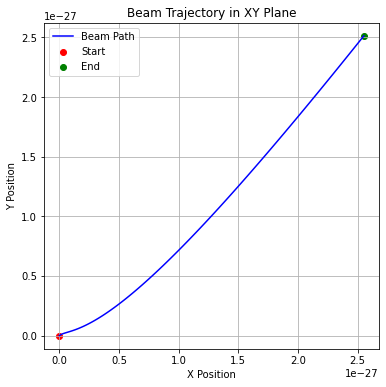

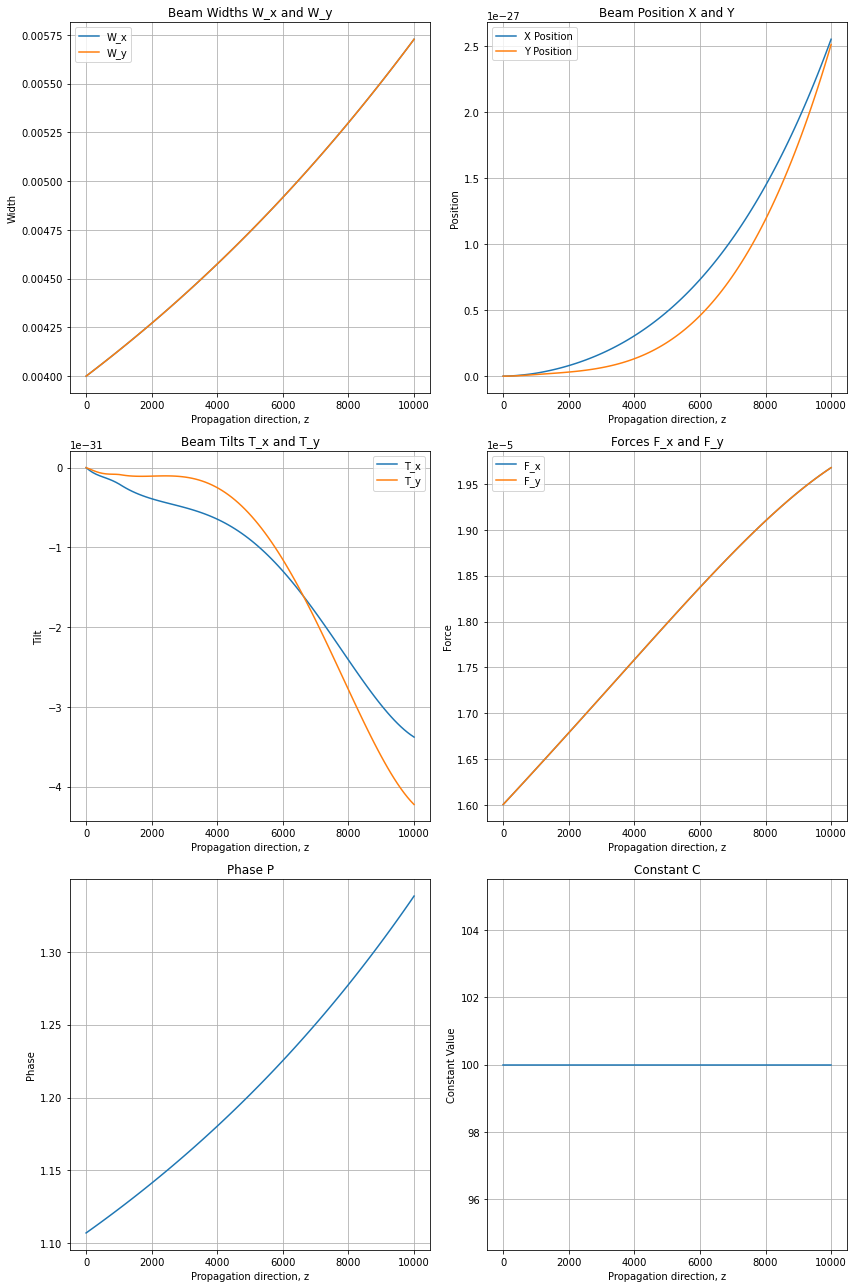

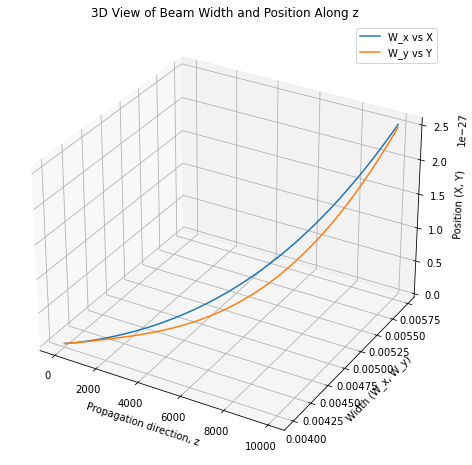

In [30]:
# Extract the results
z_values = sol.t
C_values = sol.y[0]
W_x_values = sol.y[1]
W_y_values = sol.y[2]
T_x_values = sol.y[3]
T_y_values = sol.y[4]
X_values = sol.y[5]
Y_values = sol.y[6]
F_x_values = sol.y[7]
F_y_values = sol.y[8]
P_values = sol.y[9]

results = heat_profile(y0)
plt.imshow(results, cmap='gist_heat', interpolation='gaussian', origin="lower")
plt.colorbar(label='Value')
plt.title('Heat Profile')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(X_values, Y_values, 'b-', label='Beam Path')
plt.scatter(X_values[0], Y_values[0], color='red', label='Start')  # Start point
plt.scatter(X_values[-1], Y_values[-1], color='green', label='End')  # End point
plt.title('Beam Trajectory in XY Plane')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Create a figure and axes for the plots
fig, axs = plt.subplots(3, 2, figsize=(12, 18))  # Adjust subplot layout

# Beam Widths: W_x and W_y
axs[0, 0].plot(z_values, W_x_values, label='W_x')
axs[0, 0].plot(z_values, W_y_values, label='W_y')
axs[0, 0].set_title('Beam Widths W_x and W_y')
axs[0, 0].set_xlabel('Propagation direction, z')
axs[0, 0].set_ylabel('Width')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Beam Positions: X and Y
axs[0, 1].plot(z_values, X_values, label='X Position')
axs[0, 1].plot(z_values, Y_values, label='Y Position')
axs[0, 1].set_title('Beam Position X and Y')
axs[0, 1].set_xlabel('Propagation direction, z')
axs[0, 1].set_ylabel('Position')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Beam Tilts: T_x and T_y
axs[1, 0].plot(z_values, T_x_values, label='T_x')
axs[1, 0].plot(z_values, T_y_values, label='T_y')
axs[1, 0].set_title('Beam Tilts T_x and T_y')
axs[1, 0].set_xlabel('Propagation direction, z')
axs[1, 0].set_ylabel('Tilt')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Forces: F_x and F_y
axs[1, 1].plot(z_values, F_x_values, label='F_x')
axs[1, 1].plot(z_values, F_y_values, label='F_y')
axs[1, 1].set_title('Forces F_x and F_y')
axs[1, 1].set_xlabel('Propagation direction, z')
axs[1, 1].set_ylabel('Force')
axs[1, 1].legend()
axs[1, 1].grid(True)

# Phase P
axs[2, 0].plot(z_values, P_values, label='Phase P')
axs[2, 0].set_title('Phase P')
axs[2, 0].set_xlabel('Propagation direction, z')
axs[2, 0].set_ylabel('Phase')
axs[2, 0].grid(True)

# Constants C (if needed)
axs[2, 1].plot(z_values, C_values, label='Constant C')
axs[2, 1].set_title('Constant C')
axs[2, 1].set_xlabel('Propagation direction, z')
axs[2, 1].set_ylabel('Constant Value')
axs[2, 1].grid(True)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(z_values, W_x_values, X_values, label='W_x vs X')
ax.plot(z_values, W_y_values, Y_values, label='W_y vs Y')
ax.set_xlabel('Propagation direction, z')
ax.set_ylabel('Width (W_x, W_y)')
ax.set_zlabel('Position (X, Y)')
ax.set_title('3D View of Beam Width and Position Along z')
ax.legend()

plt.show()